
# MarketGuard: ML-Based Order Book Manipulation Detection System

**Detecting spoofing-like manipulative order placement in electronic markets using
Isolation Forest, XGBoost, and SHAP explainability.**

This notebook is a full, runnable reference implementation for the MarketGuard project:

1. Data acquisition strategy (synthetic + real-data pointers)
2. A synthetic multi-agent limit order book (LOB) simulator that injects labelled spoofing behaviour
3. Order-lifecycle reconstruction and market-microstructure feature engineering
4. Participant-level behavioural profiling
5. Unsupervised anomaly detection (Isolation Forest)
6. Supervised classification (XGBoost)
7. Explainable AI layer (SHAP)
8. Visual analytics (order book depth, imbalance, risk scores, feature importance)
9. Discussion, limitations, and how to swap in real exchange data

---

### A note on data (read this first)

Genuine, publicly-available, **labelled** manipulation data essentially does not exist —
real regulators and exchanges do not release order-level data annotated with "this trader
was spoofing," both for legal and market-integrity reasons. This is a well-known problem in
the market-surveillance literature (see Wellman & Wah's agent-based spoofing model, and
Cartea, Jaimungal & Wang's "Spoofing and price manipulation in order-driven markets").

The standard academic workaround — used throughout this literature — is to **simulate** an
order book with known "spoofer" agents so that ground-truth labels exist, and validate the
pipeline there. This notebook does exactly that. Section 10 lists real, freely-downloadable
order-book datasets (LOBSTER, FI-2010, Binance) you can substitute in for the *unlabelled*,
real-world part of the pipeline (the Isolation Forest anomaly detector does not need labels
and can run directly on real data; the supervised XGBoost model is trained here on
simulated ground truth and can be used to score real participants once real features are
extracted in the same schema).


## 1. Setup

In [1]:

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.ensemble import IsolationForest
from sklearn.model_selection import train_test_split
from sklearn.metrics import (roc_auc_score, roc_curve, classification_report,
                              confusion_matrix, precision_recall_curve, average_precision_score)
import xgboost as xgb
import shap

sns.set_theme(style="whitegrid")
RNG_SEED = 42
rng = np.random.default_rng(RNG_SEED)

pd.set_option("display.max_columns", 50)



## 2. Synthetic Order Book Simulator

We simulate a single-instrument continuous double auction. Two participant archetypes
generate order flow:

- **Normal traders** (market makers, noise traders): place modestly-sized orders close to
  the touch, hold them for a while, and get filled reasonably often.
- **Spoofers**: tend to place larger orders further from the best bid/ask and cancel them
  more often, rarely intending to trade — the canonical "layering / spoofing" pattern
  described in the market-manipulation literature and in enforcement actions (e.g.
  Dodd-Frank Act 2010, MiFID II 2014).

**Important design note:** each participant's order size, distance-from-touch, and
cancellation tendency are drawn from three independent latent traits (`z_size`, `z_dist`,
`z_cancel`), each sampled from a Normal distribution whose mean differs by type but whose
variance is wide enough that the two types' distributions substantially overlap. This is
deliberate: in the first version of this simulator, spoofers and normal traders were given
hard-disjoint parameter ranges (e.g. spoofer qty always 500–3000, normal always 10–300),
which made every downstream feature perfectly separable (single-feature ROC-AUC = 1.0) and
produced a trivially-perfect classifier that told us nothing about the model. With
overlapping traits, no single feature perfectly separates the classes — some spoofers look
calm, some normal traders look aggressive — which is what real market-surveillance data
actually looks like, and is what makes the supervised/unsupervised model comparison in
Sections 6–7 meaningful rather than trivial.

The simulator tracks the live limit order book (aggregated depth per price level) and emits
an event log of `NEW`, `CANCEL`, and `EXECUTE` events with full context (best bid/ask,
mid-price, order-book imbalance at the time of the event).


In [2]:

class OrderBookSimulator:
    # Multi-agent limit order book simulator with an injected spoofer population.
    # Each participant's behaviour is driven by three independent latent traits
    # (z_size, z_dist, z_cancel) sampled per-participant from overlapping Normal
    # distributions (spoofer mean = gap, normal mean = 0, both std = 1). This means
    # no single feature perfectly separates the two classes -- some spoofers behave
    # cautiously, some normal traders behave aggressively -- matching the overlap you'd
    # expect in real market-surveillance data. See the markdown cell above for rationale.

    def __init__(self, n_normal=60, n_spoofers=12, n_steps=8000, tick=0.05,
                 start_price=100.0, seed=0, spoofer_gap=1.4):
        self.n_normal = n_normal
        self.n_spoofers = n_spoofers
        self.n_steps = n_steps
        self.tick = tick
        self.start_price = start_price
        self.rng = np.random.default_rng(seed)
        rng = self.rng

        def sig(x):
            return 1.0 / (1.0 + np.exp(-x))

        participants = []
        roster = [(i, "normal") for i in range(n_normal)] + [(i, "spoofer") for i in range(n_spoofers)]
        for i, ptype in roster:
            gap = spoofer_gap if ptype == "spoofer" else 0.0
            z_size = rng.normal(gap, 1.0)
            z_dist = rng.normal(gap, 1.0)
            z_cancel = rng.normal(gap, 1.0)
            qty_mean = 80 + 300 * sig(0.8 * z_size)
            dist_mean = 0.5 + 3.0 * sig(0.8 * (z_dist - 0.3))
            cancel_prob = float(np.clip(sig(0.9 * (z_cancel - 0.3)), 0.03, 0.97))
            participants.append({
                "id": f"{'S' if ptype == 'spoofer' else 'N'}{i:03d}", "type": ptype,
                "qty_mean": qty_mean, "dist_mean": dist_mean, "cancel_prob": cancel_prob,
            })
        self.part_df = pd.DataFrame(participants)

    def _best_bid(self, bids):
        return max(bids.keys()) if bids else None

    def _best_ask(self, asks):
        return min(asks.keys()) if asks else None

    def _imbalance(self, bids, asks):
        bb, ba = self._best_bid(bids), self._best_ask(asks)
        bq = bids.get(bb, 0) if bb else 0
        aq = asks.get(ba, 0) if ba else 0
        if bq + aq == 0:
            return 0.0
        return (bq - aq) / (bq + aq)

    def run(self):
        rng = self.rng
        bids, asks = {}, {}
        mid = self.start_price
        events = []
        open_orders = {}
        order_counter = 0

        for t in range(self.n_steps):
            mid += rng.normal(0, 0.01) + 0.02 * self._imbalance(bids, asks)
            spoof_burst = rng.random() < 0.02

            n_events = rng.poisson(1.5)
            for _ in range(n_events):
                if spoof_burst and rng.random() < 0.5:
                    p = self.part_df[self.part_df.type == "spoofer"].sample(
                        1, random_state=int(rng.integers(1e9))).iloc[0]
                else:
                    p = self.part_df.sample(1, random_state=int(rng.integers(1e9))).iloc[0]

                side = rng.choice(["BUY", "SELL"])
                bb, ba = self._best_bid(bids), self._best_ask(asks)
                ref = bb if side == "BUY" else ba
                if ref is None:
                    ref = mid

                # Per-order draws around the participant's own latent-trait means, so
                # individual orders overlap heavily between the two participant types.
                dist_ticks = max(0, int(round(rng.normal(p.dist_mean, 1.0))))
                qty = max(1, int(round(rng.normal(p.qty_mean, p.qty_mean * 0.35))))

                price = round(ref - dist_ticks * self.tick, 2) if side == "BUY" \
                    else round(ref + dist_ticks * self.tick, 2)

                order_counter += 1
                oid = f"O{order_counter:07d}"

                # One-shot cancel decision at submission time (rather than re-rolling a
                # cancel probability every tick): repeated per-tick Bernoulli trials
                # converge to near-certain cancellation for almost any positive
                # probability given enough ticks, which erases the overlap between
                # participant types. A single draw per order preserves it.
                will_cancel = rng.random() < p.cancel_prob
                cancel_delay = int(rng.integers(1, 6)) if will_cancel else None

                open_orders[oid] = {"side": side, "price": price, "qty_remaining": qty,
                                     "qty_submitted": qty, "participant": p.id,
                                     "ptype": p.type, "submit_t": t, "n_mods": 0,
                                     "cancel_delay": cancel_delay}
                book = bids if side == "BUY" else asks
                book[price] = book.get(price, 0) + qty

                events.append({"t": t, "event": "NEW", "order_id": oid,
                                "participant": p.id, "ptype": p.type, "side": side,
                                "price": price, "qty": qty,
                                "best_bid": self._best_bid(bids), "best_ask": self._best_ask(asks),
                                "mid": mid, "imbalance": self._imbalance(bids, asks)})

            bb, ba = self._best_bid(bids), self._best_ask(asks)
            if bb is not None and ba is not None and rng.random() < 0.3:
                side_hit = rng.choice(["BUY", "SELL"])
                book = asks if side_hit == "BUY" else bids
                lvl = self._best_ask(asks) if side_hit == "BUY" else self._best_bid(bids)
                if lvl is not None and book.get(lvl, 0) > 0:
                    hit_qty = min(book[lvl], rng.integers(10, 200))
                    book[lvl] -= hit_qty
                    remaining = hit_qty
                    candidates = [oid for oid, o in open_orders.items()
                                  if o["price"] == lvl and o["qty_remaining"] > 0 and
                                  o["side"] == ("SELL" if side_hit == "BUY" else "BUY")]
                    for oid in candidates:
                        if remaining <= 0:
                            break
                        o = open_orders[oid]
                        fill = min(o["qty_remaining"], remaining)
                        o["qty_remaining"] -= fill
                        remaining -= fill
                        events.append({"t": t, "event": "EXECUTE", "order_id": oid,
                                        "participant": o["participant"], "ptype": o["ptype"],
                                        "side": o["side"], "price": lvl, "qty": fill,
                                        "best_bid": self._best_bid(bids), "best_ask": self._best_ask(asks),
                                        "mid": mid, "imbalance": self._imbalance(bids, asks)})
                    if book.get(lvl, 0) <= 0:
                        book.pop(lvl, None)

            to_remove = []
            for oid, o in list(open_orders.items()):
                if o["qty_remaining"] <= 0:
                    to_remove.append(oid)
                    continue
                age = t - o["submit_t"]
                if o["cancel_delay"] is not None and age >= o["cancel_delay"]:
                    book = bids if o["side"] == "BUY" else asks
                    book[o["price"]] = book.get(o["price"], 0) - o["qty_remaining"]
                    if book[o["price"]] <= 0:
                        book.pop(o["price"], None)
                    events.append({"t": t, "event": "CANCEL", "order_id": oid,
                                    "participant": o["participant"], "ptype": o["ptype"],
                                    "side": o["side"], "price": o["price"], "qty": o["qty_remaining"],
                                    "best_bid": self._best_bid(bids), "best_ask": self._best_ask(asks),
                                    "mid": mid, "imbalance": self._imbalance(bids, asks)})
                    to_remove.append(oid)
            for oid in to_remove:
                open_orders.pop(oid, None)

        return pd.DataFrame(events)



## 3. Generate the Dataset (multiple trading sessions)

Real behavioural profiling is done per participant *per trading session*, so we run the
simulator across several independent "days" and stack the resulting event logs. This gives
us many more participant-session observations to train and validate on than a single run.


In [3]:

N_SESSIONS = 25

all_events = []
for session in range(N_SESSIONS):
    sim = OrderBookSimulator(n_normal=60, n_spoofers=12, n_steps=4000, seed=1000 + session)
    ev = sim.run()
    ev["session"] = session
    all_events.append(ev)

events_df = pd.concat(all_events, ignore_index=True)
print(f"Total events: {len(events_df):,}")
print(events_df["event"].value_counts())
events_df.head()


Total events: 267,136
event
NEW        150218
CANCEL      73601
EXECUTE     43317
Name: count, dtype: int64


,t,event,order_id,participant,ptype,side,price,qty,best_bid,best_ask,mid,imbalance,session
0,0,NEW,O0000001,N056,normal,SELL,100.16,82,NaN,100.16,100.006130,-1.000000,0
1,1,NEW,O0000002,N018,normal,BUY,99.98,321,99.98,100.16,99.981651,0.593052,0
2,1,NEW,O0000003,S002,spoofer,BUY,99.78,305,99.98,100.16,99.981651,0.593052,0
3,1,NEW,O0000004,N025,normal,SELL,100.21,190,99.98,100.16,99.981651,0.593052,0
4,1,EXECUTE,O0000001,N056,normal,SELL,100.16,82,99.98,100.16,99.981651,1.000000,0


In [4]:

# Persist the raw simulated event log (this plays the role of the "ingested order-level
# market data" described in the problem statement: timestamps, prices, quantities, event types)
events_df.to_csv("marketguard_simulated_events.csv", index=False)
events_df.groupby(["session", "ptype"])["event"].count().unstack().head()


ptype,normal,spoofer
session,,
0,8792,1934
1,8750,1923
2,8737,1860
3,8717,1863
4,8741,1902



## 4. Order Lifecycle Reconstruction & Feature Engineering

Each order is tracked from submission through to cancellation or execution. From this we
derive the market microstructure features called for in the project brief:

| Feature | Description |
|---|---|
| `cancel_ratio` | Share of a participant's orders cancelled rather than filled |
| `avg_lifetime` | Average time (in simulation steps) an order stays open |
| `fill_ratio` / `overall_fill_ratio` | Executed quantity vs. submitted quantity |
| `avg_order_size` | Order size — spoofers post unusually large size |
| `avg_dist_from_touch` | How far from the best bid/ask orders are placed |
| `avg_imbalance_at_submit` | Order-book imbalance at the moment of submission (spoofers tend to submit when/because they are creating imbalance) |
| `orders_per_session` | Order submission rate |
| `mod_frequency` | (placeholder — extend with MODIFY events if your source data has them) |


In [5]:

def reconstruct_orders(df):
    # IMPORTANT: order_id is only unique *within* a session (the simulator's order counter
    # restarts each run), so every groupby/merge below must key on (session, order_id)
    # together -- keying on order_id alone silently merges unrelated orders from different
    # sessions and produces nonsensical fill ratios.
    orders = df.groupby(["session", "order_id"]).agg(
        participant=("participant", "first"),
        ptype=("ptype", "first"),
        side=("side", "first"),
        submit_price=("price", "first"),
        submit_t=("t", "first"),
        last_t=("t", "last"),
    ).reset_index()

    new_ev = df[df.event == "NEW"][["session", "order_id", "qty", "best_bid", "best_ask", "imbalance"]].rename(
        columns={"qty": "submitted_qty", "best_bid": "bb_at_submit",
                 "best_ask": "ba_at_submit", "imbalance": "imb_at_submit"})
    orders = orders.merge(new_ev, on=["session", "order_id"], how="left")

    exec_qty = df[df.event == "EXECUTE"].groupby(["session", "order_id"])["qty"].sum().rename("executed_qty")
    orders = orders.merge(exec_qty, on=["session", "order_id"], how="left")
    orders["executed_qty"] = orders["executed_qty"].fillna(0)

    cancelled_ids = set(map(tuple, df[df.event == "CANCEL"][["session", "order_id"]].values))
    orders["was_cancelled"] = orders.apply(lambda r: (r["session"], r["order_id"]) in cancelled_ids, axis=1)

    orders["lifetime"] = orders["last_t"] - orders["submit_t"]
    orders["fill_ratio"] = (orders["executed_qty"] / orders["submitted_qty"].replace(0, np.nan)).fillna(0)

    orders["dist_from_touch"] = np.where(
        orders["side"] == "BUY",
        (orders["bb_at_submit"] - orders["submit_price"]).abs(),
        (orders["submit_price"] - orders["ba_at_submit"]).abs(),
    ).astype(float)
    orders["dist_from_touch"] = orders["dist_from_touch"].fillna(0)
    return orders


orders_df = reconstruct_orders(events_df)
orders_df.head()


,session,order_id,participant,ptype,side,submit_price,submit_t,last_t,submitted_qty,bb_at_submit,ba_at_submit,imb_at_submit,executed_qty,was_cancelled,lifetime,fill_ratio,dist_from_touch
0,0,O0000001,N056,normal,SELL,100.16,0,1,82,NaN,100.16,-1.000000,82.0,False,1,1.000000,0.00
1,0,O0000002,N018,normal,BUY,99.98,1,5,321,99.98,100.16,0.593052,47.0,True,4,0.146417,0.00
2,0,O0000003,S002,spoofer,BUY,99.78,1,5,305,99.98,100.16,0.593052,0.0,True,4,0.000000,0.20
3,0,O0000004,N025,normal,SELL,100.21,1,5,190,99.98,100.16,0.593052,110.0,True,4,0.578947,0.05
4,0,O0000005,N008,normal,SELL,100.31,2,14,257,99.98,100.21,0.256360,257.0,False,12,1.000000,0.10


In [6]:

def build_participant_features(orders):
    agg = orders.groupby(["participant", "ptype", "session"]).agg(
        n_orders=("order_id", "count"),
        cancel_ratio=("was_cancelled", "mean"),
        avg_lifetime=("lifetime", "mean"),
        fill_ratio=("fill_ratio", "mean"),
        avg_order_size=("submitted_qty", "mean"),
        avg_dist_from_touch=("dist_from_touch", "mean"),
        avg_imbalance_at_submit=("imb_at_submit", "mean"),
        total_submitted_qty=("submitted_qty", "sum"),
        total_executed_qty=("executed_qty", "sum"),
    ).reset_index()

    agg["overall_fill_ratio"] = agg["total_executed_qty"] / agg["total_submitted_qty"]
    agg["label"] = (agg["ptype"] == "spoofer").astype(int)
    return agg


participant_features = build_participant_features(orders_df)
participant_features.to_csv("marketguard_participant_features.csv", index=False)
print(participant_features.shape)
participant_features.groupby("ptype")[
    ["cancel_ratio", "avg_lifetime", "fill_ratio", "avg_order_size", "avg_dist_from_touch"]
].mean()


(1800, 14)


,cancel_ratio,avg_lifetime,fill_ratio,avg_order_size,avg_dist_from_touch
ptype,,,,,
normal,0.445599,115.107565,0.103886,228.158054,0.092248
spoofer,0.695526,39.816733,0.027557,295.977413,0.129421


## 5. Exploratory Analytics

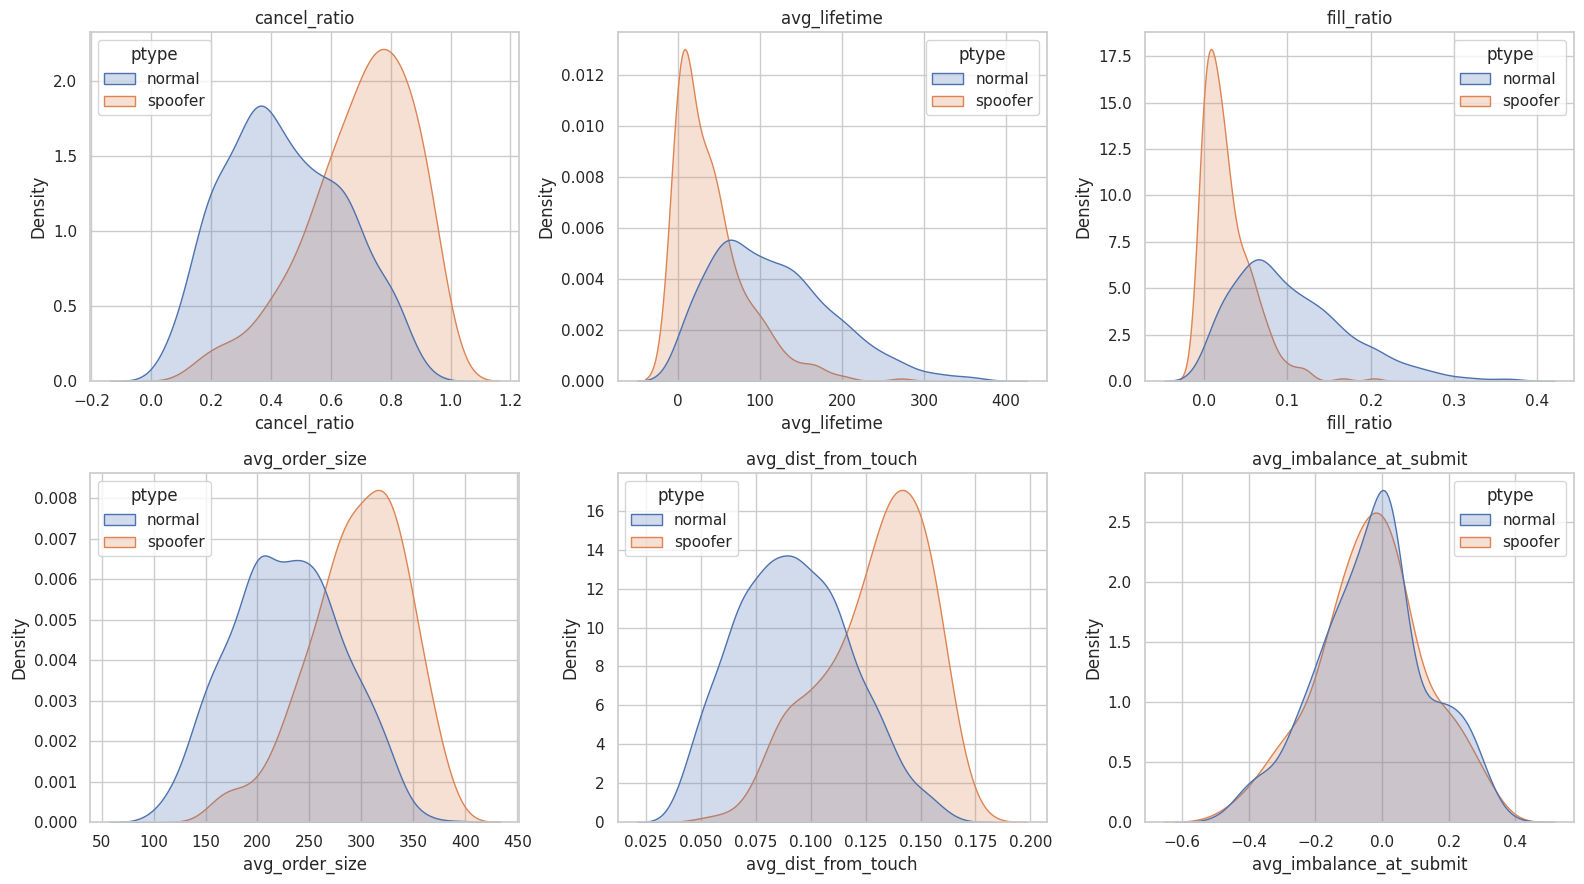

In [7]:

fig, axes = plt.subplots(2, 3, figsize=(16, 9))
feat_plot_cols = ["cancel_ratio", "avg_lifetime", "fill_ratio",
                   "avg_order_size", "avg_dist_from_touch", "avg_imbalance_at_submit"]
for ax, col in zip(axes.flat, feat_plot_cols):
    sns.kdeplot(data=participant_features, x=col, hue="ptype", fill=True, common_norm=False, ax=ax)
    ax.set_title(col)
plt.tight_layout()
plt.savefig("feature_distributions.png", dpi=120)
plt.show()


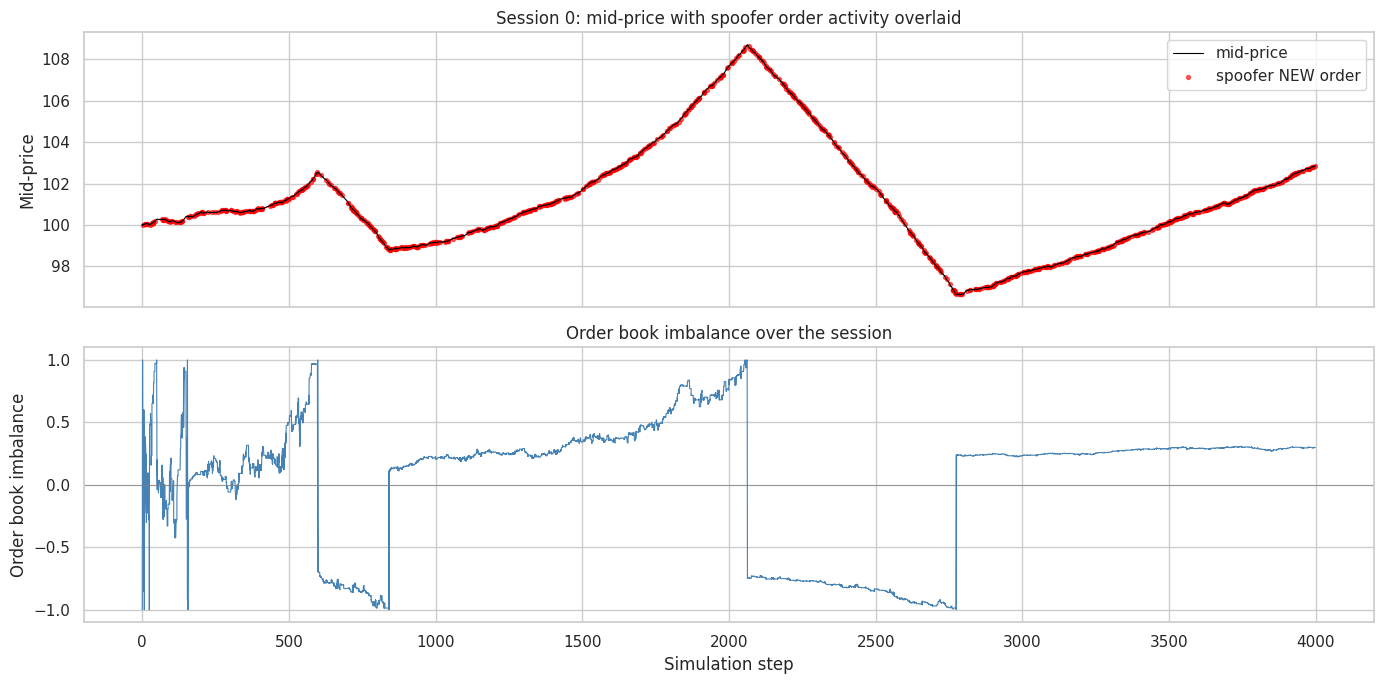

In [8]:

# Order book depth snapshot + mid-price path for one session, to visualize spoofing bursts
sess0 = events_df[events_df.session == 0].sort_values("t")

fig, axes = plt.subplots(2, 1, figsize=(14, 7), sharex=True)
axes[0].plot(sess0["t"], sess0["mid"], color="black", lw=0.8, label="mid-price")
spoof_new = sess0[(sess0.event == "NEW") & (sess0.ptype == "spoofer")]
axes[0].scatter(spoof_new["t"], spoof_new["mid"], color="red", s=8, alpha=0.6, label="spoofer NEW order")
axes[0].set_ylabel("Mid-price")
axes[0].legend(loc="upper right")
axes[0].set_title("Session 0: mid-price with spoofer order activity overlaid")

axes[1].plot(sess0["t"], sess0["imbalance"], color="steelblue", lw=0.8)
axes[1].axhline(0, color="gray", lw=0.5)
axes[1].set_ylabel("Order book imbalance")
axes[1].set_xlabel("Simulation step")
axes[1].set_title("Order book imbalance over the session")
plt.tight_layout()
plt.savefig("session_overview.png", dpi=120)
plt.show()



## 6. Unsupervised Detection — Isolation Forest

Isolation Forest requires no labels: it flags participant-session profiles that are
structurally "easy to isolate" in feature space. This mirrors how a real surveillance system
would work on unlabelled live market data before any confirmed manipulation cases exist.


In [9]:

FEATURE_COLS = ["n_orders", "cancel_ratio", "avg_lifetime", "fill_ratio",
                "avg_order_size", "avg_dist_from_touch", "avg_imbalance_at_submit",
                "overall_fill_ratio"]

X = participant_features[FEATURE_COLS].fillna(0)
y = participant_features["label"]

contamination = float(y.mean())
iso = IsolationForest(n_estimators=300, contamination=contamination, random_state=RNG_SEED)
iso.fit(X)

participant_features["iso_anomaly_score"] = -iso.score_samples(X)   # higher = more anomalous
participant_features["iso_flag"] = (iso.predict(X) == -1).astype(int)

iso_auc = roc_auc_score(y, participant_features["iso_anomaly_score"])
print(f"Isolation Forest ROC-AUC vs. ground-truth spoofer label: {iso_auc:.4f}")
print(f"Contamination (assumed spoofer prevalence) used: {contamination:.3f}")


Isolation Forest ROC-AUC vs. ground-truth spoofer label: 0.6467
Contamination (assumed spoofer prevalence) used: 0.167


### 5b. Feature separability check

Before trusting any model's accuracy number, it's worth checking how much of the work a *single* feature already does on its own. If one feature alone gives ROC-AUC = 1.0, a "99% accurate model" is really just rediscovering a threshold rule, not learning anything. With the overlapping-trait simulator design above, no single feature should perfectly separate the classes.

In [10]:
single_feature_auc = pd.Series(
    {col: roc_auc_score(y, X[col]) for col in FEATURE_COLS}
).sort_values(ascending=False)
print("Single-feature ROC-AUC (each feature alone vs. the label):")
print(single_feature_auc.round(4))


Single-feature ROC-AUC (each feature alone vs. the label):
avg_dist_from_touch        0.8472
avg_order_size             0.8281
cancel_ratio               0.8187
n_orders                   0.6653
avg_imbalance_at_submit    0.4946
avg_lifetime               0.1739
overall_fill_ratio         0.1356
fill_ratio                 0.1291
dtype: float64



## 7. Supervised Classification — XGBoost

Where confirmed manipulation cases exist (regulatory findings, internal surveillance
confirmations, or — as here — simulated ground truth), a supervised model learns richer,
non-linear interactions between features and produces a calibrated probability of
manipulation for each participant-session.


In [11]:

X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.3, random_state=RNG_SEED, stratify=y
)

xgb_clf = xgb.XGBClassifier(
    n_estimators=200, max_depth=4, learning_rate=0.08,
    subsample=0.9, colsample_bytree=0.9,
    eval_metric="logloss", random_state=RNG_SEED
)
xgb_clf.fit(X_train, y_train)

proba_test = xgb_clf.predict_proba(X_test)[:, 1]
pred_test = xgb_clf.predict(X_test)

print(f"XGBoost ROC-AUC:  {roc_auc_score(y_test, proba_test):.4f}")
print(f"XGBoost PR-AUC:   {average_precision_score(y_test, proba_test):.4f}")
print()
print(classification_report(y_test, pred_test, target_names=["normal", "spoofer"]))


XGBoost ROC-AUC:  0.9440
XGBoost PR-AUC:   0.8242

              precision    recall  f1-score   support

      normal       0.94      0.95      0.95       450
     spoofer       0.74      0.71      0.72        90

    accuracy                           0.91       540
   macro avg       0.84      0.83      0.83       540
weighted avg       0.91      0.91      0.91       540



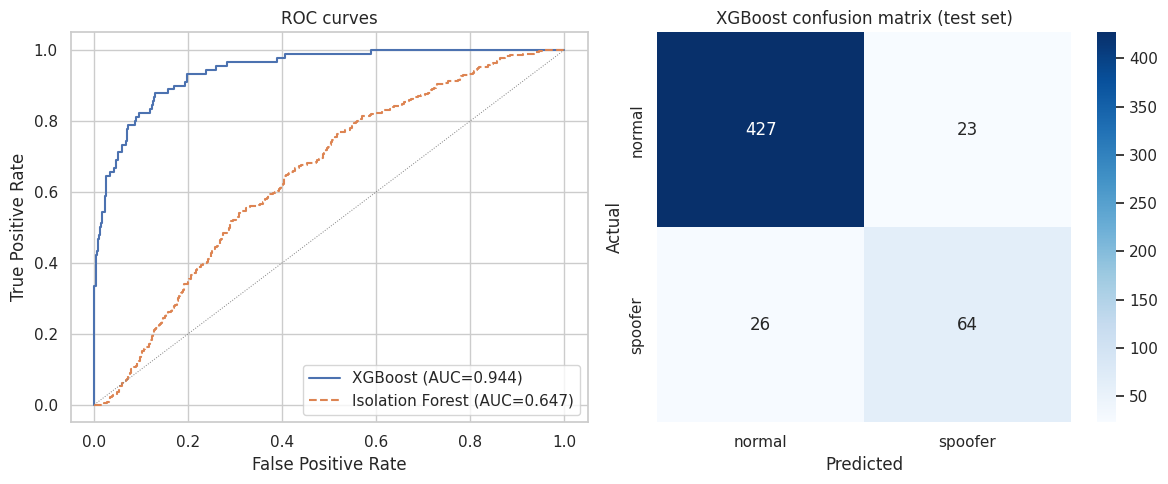

In [12]:

fig, axes = plt.subplots(1, 2, figsize=(12, 5))

fpr, tpr, _ = roc_curve(y_test, proba_test)
axes[0].plot(fpr, tpr, label=f"XGBoost (AUC={roc_auc_score(y_test, proba_test):.3f})")
iso_fpr, iso_tpr, _ = roc_curve(y, participant_features["iso_anomaly_score"])
axes[0].plot(iso_fpr, iso_tpr, label=f"Isolation Forest (AUC={iso_auc:.3f})", linestyle="--")
axes[0].plot([0, 1], [0, 1], color="gray", lw=0.7, linestyle=":")
axes[0].set_xlabel("False Positive Rate"); axes[0].set_ylabel("True Positive Rate")
axes[0].set_title("ROC curves"); axes[0].legend()

cm = confusion_matrix(y_test, pred_test)
sns.heatmap(cm, annot=True, fmt="d", cmap="Blues", ax=axes[1],
            xticklabels=["normal", "spoofer"], yticklabels=["normal", "spoofer"])
axes[1].set_xlabel("Predicted"); axes[1].set_ylabel("Actual")
axes[1].set_title("XGBoost confusion matrix (test set)")
plt.tight_layout()
plt.savefig("model_evaluation.png", dpi=120)
plt.show()



## 8. Explainable AI Layer — SHAP

For every flagged participant-session, SHAP values show exactly which behavioural features
pushed the model's decision, and by how much — satisfying the "risk scores and explanations"
objective from the brief.


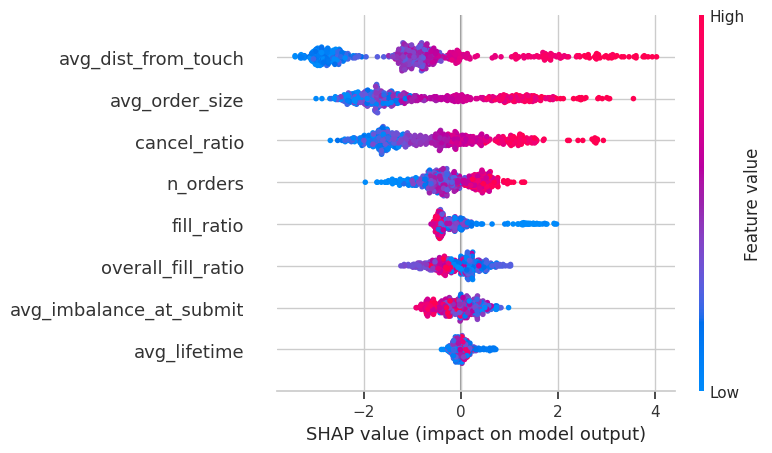

In [13]:

explainer = shap.TreeExplainer(xgb_clf)
shap_values = explainer.shap_values(X_test)

shap.summary_plot(shap_values, X_test, show=False)
plt.tight_layout()
plt.savefig("shap_summary.png", dpi=120, bbox_inches="tight")
plt.show()


Highest-risk participant-session (test set) feature values:
n_orders                    74.000000
cancel_ratio                 0.905405
avg_lifetime                 2.621622
fill_ratio                   0.000000
avg_order_size             366.445946
avg_dist_from_touch          0.150000
avg_imbalance_at_submit      0.071290
overall_fill_ratio           0.000000
Name: 1750, dtype: float64

Predicted manipulation probability: 0.999


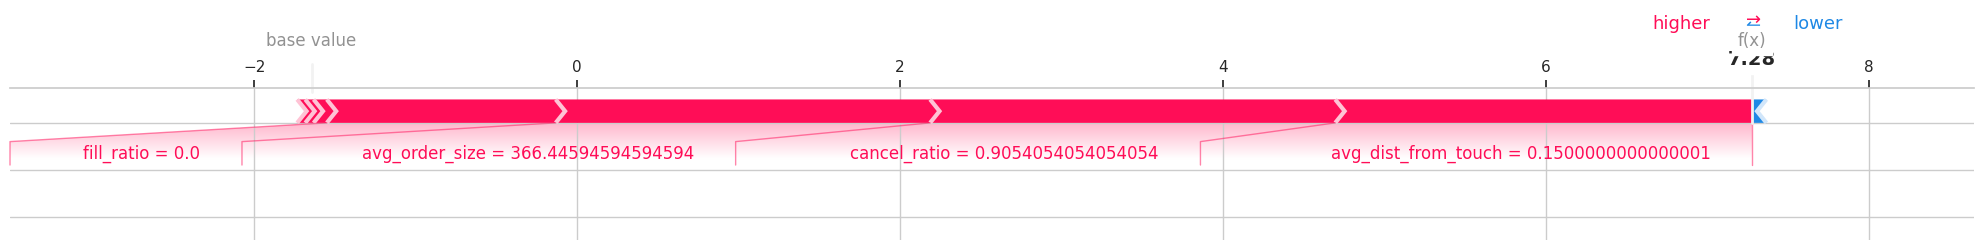

In [14]:

# Explain the single highest-risk participant-session in the test set
top_idx = np.argsort(proba_test)[-1]
top_row = X_test.iloc[top_idx]
print("Highest-risk participant-session (test set) feature values:")
print(top_row)
print(f"\nPredicted manipulation probability: {proba_test[top_idx]:.3f}")

shap.force_plot(
    explainer.expected_value, shap_values[top_idx], X_test.iloc[top_idx],
    matplotlib=True, show=False
)
plt.tight_layout()
plt.savefig("shap_force_top_risk.png", dpi=120, bbox_inches="tight")
plt.show()


## 9. Risk Scoring Dashboard (static view)

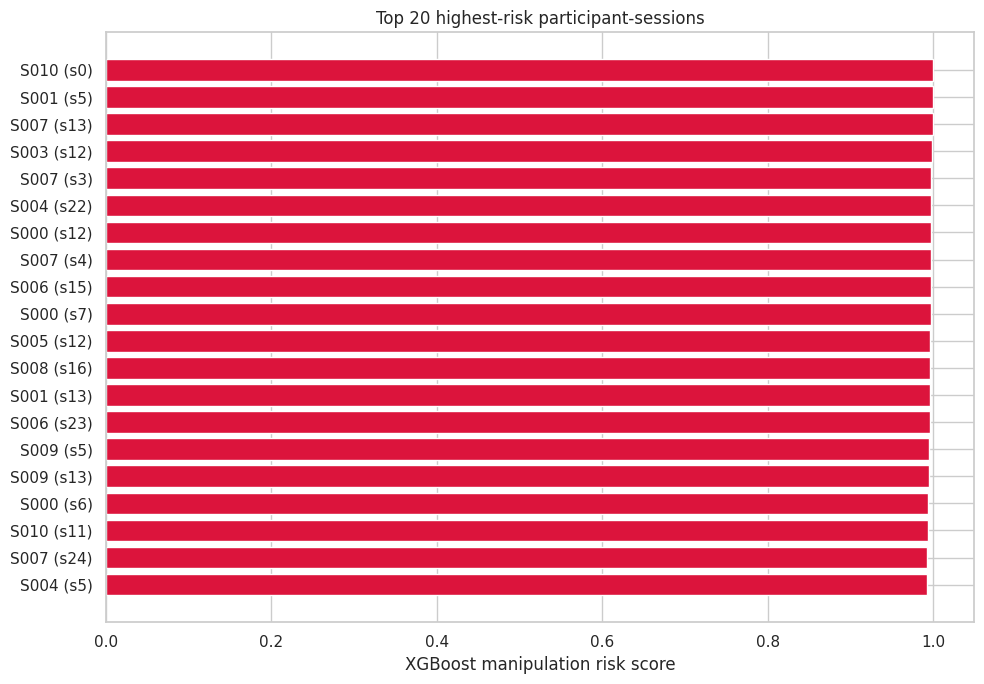

,participant,session,ptype,xgb_risk_score,iso_anomaly_score,cancel_ratio,avg_order_size,avg_dist_from_touch
1750,S010,0,spoofer,0.999310,0.535888,0.905405,366.445946,0.150000
1530,S001,5,spoofer,0.999209,0.538808,0.964286,351.238095,0.155952
1688,S007,13,spoofer,0.999180,0.516310,0.925926,349.185185,0.152469
1587,S003,12,spoofer,0.998735,0.532573,0.975610,347.109756,0.143902
1678,S007,3,spoofer,0.997716,0.503870,0.897727,335.022727,0.148864
1622,S004,22,spoofer,0.997577,0.526717,0.873239,343.450704,0.153521
1512,S000,12,spoofer,0.997461,0.520481,0.931818,321.602273,0.155114
1679,S007,4,spoofer,0.997460,0.580949,0.897727,349.625000,0.167045
1665,S006,15,spoofer,0.997283,0.512735,0.931818,289.397727,0.175568
1507,S000,7,spoofer,0.996891,0.524734,0.752688,382.763441,0.153763


In [15]:

participant_features["xgb_risk_score"] = np.nan
X_all_idx = X.index
participant_features.loc[X_all_idx, "xgb_risk_score"] = xgb_clf.predict_proba(X)[:, 1]

top20 = participant_features.sort_values("xgb_risk_score", ascending=False).head(20)

fig, ax = plt.subplots(figsize=(10, 7))
colors = top20["ptype"].map({"spoofer": "crimson", "normal": "steelblue"})
ax.barh(top20["participant"] + " (s" + top20["session"].astype(str) + ")",
        top20["xgb_risk_score"], color=colors)
ax.invert_yaxis()
ax.set_xlabel("XGBoost manipulation risk score")
ax.set_title("Top 20 highest-risk participant-sessions")
plt.tight_layout()
plt.savefig("risk_leaderboard.png", dpi=120)
plt.show()

top20[["participant", "session", "ptype", "xgb_risk_score", "iso_anomaly_score",
       "cancel_ratio", "avg_order_size", "avg_dist_from_touch"]]


## 10. From-Scratch Models + Test on Unseen Data

To make sure the detector isn't just an artifact of `sklearn`'s/`xgboost`'s specific implementations, this section reimplements both models **from scratch with numpy only**:

- `OwnIsolationForest` — same algorithm as sklearn's Isolation Forest (random-split trees, anomaly score from average path length), built from raw isolation trees.
- `OwnGradientBoostedClassifier` — a simplified XGBoost-style booster: additive regression trees fit on the gradient/Hessian of the logistic loss (Newton boosting), using the same split-gain formula XGBoost uses internally.

Both are then trained on the original data and evaluated on **brand-new simulated sessions the models have never seen** (fresh seeds, offset session IDs so they can't collide with training data), with a sanity comparison against the original sklearn/XGBoost models on the same new data.

In [16]:
# ============================================================
# 10. From-scratch models (no sklearn IsolationForest, no XGBoost)
#     + evaluation on brand-new, unseen simulated sessions
# ============================================================

class OwnIsolationTree:
    def __init__(self, max_depth):
        self.max_depth = max_depth
        self.is_leaf = True
        self.split_feat = None
        self.split_val = None
        self.left = None
        self.right = None
        self.size = 0

    def fit(self, X, rng, depth=0):
        self.size = X.shape[0]
        if depth >= self.max_depth or self.size <= 1:
            return self
        n_features = X.shape[1]
        feat_order = rng.permutation(n_features)
        for feat in feat_order:
            col = X[:, feat]
            lo, hi = col.min(), col.max()
            if lo < hi:
                split_val = rng.uniform(lo, hi)
                left_mask = col < split_val
                if left_mask.any() and (~left_mask).any():
                    self.is_leaf = False
                    self.split_feat = feat
                    self.split_val = split_val
                    self.left = OwnIsolationTree(self.max_depth).fit(X[left_mask], rng, depth + 1)
                    self.right = OwnIsolationTree(self.max_depth).fit(X[~left_mask], rng, depth + 1)
                    return self
        return self  # no usable split found -> leaf

    def path_length(self, x, depth=0):
        if self.is_leaf:
            return depth + _c_factor(self.size)
        branch = self.left if x[self.split_feat] < self.split_val else self.right
        return branch.path_length(x, depth + 1)


def _c_factor(n):
    if n <= 1:
        return 0.0
    return 2.0 * (np.log(n - 1) + 0.5772156649) - 2.0 * (n - 1) / n


class OwnIsolationForest:
    """From-scratch isolation forest: ensemble of random-split trees,
    anomaly score = 2^(-avg_path_length / c(sample_size)). Higher = more anomalous."""
    def __init__(self, n_estimators=200, sample_size=256, random_state=0):
        self.n_estimators = n_estimators
        self.sample_size = sample_size
        self.random_state = random_state
        self.trees = []
        self.sample_size_ = None

    def fit(self, X):
        X = np.asarray(X, dtype=float)
        n = X.shape[0]
        self.sample_size_ = min(self.sample_size, n)
        max_depth = int(np.ceil(np.log2(max(self.sample_size_, 2))))
        local_rng = np.random.default_rng(self.random_state)
        self.trees = []
        for i in range(self.n_estimators):
            idx = local_rng.choice(n, size=self.sample_size_, replace=False)
            tree_rng = np.random.default_rng(self.random_state + i + 1)
            tree = OwnIsolationTree(max_depth)
            tree.fit(X[idx], tree_rng)
            self.trees.append(tree)
        return self

    def anomaly_score(self, X):
        X = np.asarray(X, dtype=float)
        c = _c_factor(self.sample_size_)
        scores = np.empty(X.shape[0])
        for i, x in enumerate(X):
            avg_path = np.mean([t.path_length(x) for t in self.trees])
            scores[i] = 2 ** (-avg_path / c)
        return scores


class OwnRegressionTree:
    """CART-style regression tree fit on gradients/Hessians (Newton-boosting split
    criterion, same gain formula XGBoost uses), built entirely with numpy."""
    def __init__(self, max_depth=3, min_samples_leaf=5, lam=1.0):
        self.max_depth = max_depth
        self.min_samples_leaf = min_samples_leaf
        self.lam = lam
        self.is_leaf = True
        self.value = 0.0
        self.feat = None
        self.thresh = None
        self.left = None
        self.right = None

    def _leaf_value(self, g, h):
        return -g.sum() / (h.sum() + self.lam)

    def _gain(self, g, h, mask):
        gl, hl = g[mask].sum(), h[mask].sum()
        gr, hr = g[~mask].sum(), h[~mask].sum()
        return 0.5 * (gl**2 / (hl + self.lam) + gr**2 / (hr + self.lam)
                      - (gl + gr)**2 / (hl + hr + self.lam))

    def fit(self, X, g, h, depth=0):
        self.value = self._leaf_value(g, h)
        n, d = X.shape
        if depth >= self.max_depth or n < 2 * self.min_samples_leaf:
            return self
        best_gain, best_feat, best_thr, best_mask = 1e-12, None, None, None
        for feat in range(d):
            col = X[:, feat]
            candidates = np.unique(col)
            if len(candidates) < 2:
                continue
            if len(candidates) > 32:
                candidates = np.quantile(candidates, np.linspace(0, 1, 32))
            for thr in candidates[:-1]:
                mask = col <= thr
                if mask.sum() < self.min_samples_leaf or (~mask).sum() < self.min_samples_leaf:
                    continue
                gain = self._gain(g, h, mask)
                if gain > best_gain:
                    best_gain, best_feat, best_thr, best_mask = gain, feat, thr, mask
        if best_feat is None:
            return self
        self.is_leaf = False
        self.feat, self.thresh = best_feat, best_thr
        self.left = OwnRegressionTree(self.max_depth, self.min_samples_leaf, self.lam).fit(
            X[best_mask], g[best_mask], h[best_mask], depth + 1)
        self.right = OwnRegressionTree(self.max_depth, self.min_samples_leaf, self.lam).fit(
            X[~best_mask], g[~best_mask], h[~best_mask], depth + 1)
        return self

    def predict(self, X):
        return np.array([self._predict_one(x) for x in X])

    def _predict_one(self, x):
        node = self
        while not node.is_leaf:
            node = node.left if x[node.feat] <= node.thresh else node.right
        return node.value


class OwnGradientBoostedClassifier:
    """From-scratch, simplified XGBoost-style binary classifier: additive
    regression trees fit on the gradient/Hessian of the logistic loss."""
    def __init__(self, n_estimators=150, max_depth=3, learning_rate=0.1, lam=1.0):
        self.n_estimators = n_estimators
        self.max_depth = max_depth
        self.learning_rate = learning_rate
        self.lam = lam
        self.trees = []
        self.base_score = 0.0

    def fit(self, X, y):
        X = np.asarray(X, dtype=float)
        y = np.asarray(y, dtype=float)
        p0 = np.clip(y.mean(), 1e-6, 1 - 1e-6)
        self.base_score = np.log(p0 / (1 - p0))
        F = np.full(len(y), self.base_score)
        self.trees = []
        for _ in range(self.n_estimators):
            p_hat = 1.0 / (1.0 + np.exp(-F))
            g = p_hat - y
            h = p_hat * (1 - p_hat)
            tree = OwnRegressionTree(self.max_depth, min_samples_leaf=5, lam=self.lam)
            tree.fit(X, g, h)
            F += self.learning_rate * tree.predict(X)
            self.trees.append(tree)
        return self

    def predict_proba(self, X):
        X = np.asarray(X, dtype=float)
        F = np.full(X.shape[0], self.base_score)
        for tree in self.trees:
            F += self.learning_rate * tree.predict(X)
        p = 1.0 / (1.0 + np.exp(-F))
        return np.column_stack([1 - p, p])

    def predict(self, X, threshold=0.5):
        return (self.predict_proba(X)[:, 1] >= threshold).astype(int)


# ---- Fit own models on the existing training data ----
own_iso = OwnIsolationForest(n_estimators=200, sample_size=256, random_state=RNG_SEED).fit(X.values)
own_gbm = OwnGradientBoostedClassifier(n_estimators=150, max_depth=3, learning_rate=0.1, lam=1.0).fit(
    X_train.values, y_train.values)

# ---- Generate genuinely new, unseen sessions (own models have never seen these) ----
NEW_SESSIONS = 8
new_events = []
for s in range(NEW_SESSIONS):
    sim_new = OrderBookSimulator(n_normal=60, n_spoofers=12, n_steps=4000, seed=9000 + s)
    ev_new = sim_new.run()
    ev_new["session"] = 1000 + s  # offset so ids never collide with training sessions
    new_events.append(ev_new)
new_events_df = pd.concat(new_events, ignore_index=True)

new_orders_df = reconstruct_orders(new_events_df)
new_participant_features = build_participant_features(new_orders_df)

X_new = new_participant_features[FEATURE_COLS].fillna(0)
y_new = new_participant_features["label"]

new_iso_scores = own_iso.anomaly_score(X_new.values)
new_gbm_proba = own_gbm.predict_proba(X_new.values)[:, 1]
new_gbm_pred = own_gbm.predict(X_new.values)

print(f"New unseen participant-sessions: {len(X_new)}")
print(f"[Own Isolation Forest]        ROC-AUC on new sessions: {roc_auc_score(y_new, new_iso_scores):.4f}")
print(f"[Own Gradient Boosted Trees]  ROC-AUC on new sessions: {roc_auc_score(y_new, new_gbm_proba):.4f}")
print(f"[Own Gradient Boosted Trees]  PR-AUC  on new sessions: {average_precision_score(y_new, new_gbm_proba):.4f}")
print()
print(classification_report(y_new, new_gbm_pred, target_names=["normal", "spoofer"]))

# Sanity comparison against the sklearn / xgboost models on the same new data
sk_iso_scores_new = -iso.score_samples(X_new)
sk_xgb_proba_new = xgb_clf.predict_proba(X_new)[:, 1]
print(f"[sklearn IsolationForest]     ROC-AUC on new sessions: {roc_auc_score(y_new, sk_iso_scores_new):.4f}")
print(f"[xgboost XGBClassifier]       ROC-AUC on new sessions: {roc_auc_score(y_new, sk_xgb_proba_new):.4f}")


New unseen participant-sessions: 576
[Own Isolation Forest]        ROC-AUC on new sessions: 0.6064
[Own Gradient Boosted Trees]  ROC-AUC on new sessions: 0.9534
[Own Gradient Boosted Trees]  PR-AUC  on new sessions: 0.8640

              precision    recall  f1-score   support

      normal       0.94      0.98      0.96       480
     spoofer       0.88      0.68      0.76        96

    accuracy                           0.93       576
   macro avg       0.91      0.83      0.86       576
weighted avg       0.93      0.93      0.93       576

[sklearn IsolationForest]     ROC-AUC on new sessions: 0.6261
[xgboost XGBClassifier]       ROC-AUC on new sessions: 0.9503
